# Gate-fidelity-corrected data processing and figures

This notebook now includes both **gate-fidelity-corrected FI analysis** and SI figure assembly. It can regenerate corrected `alpha, P, FI` CSV products from raw singlet data, then load those products for plotting.

## Inputs
- `data/singlet_U{ x,y,z }_t_list_1218.csv`
- `data/singlet_U{ x,y,z }_P_1218.csv`
- `data_analysis/singlet_U{ x,y,z }_alpha_P_FI_1218_readout_and_gate_corrected.csv` (generated here, then consumed for plotting)

## Outputs
- `si_figures/SI_fig_v3_c_gate.pdf` (plus intermediate combined-panel exports)

```mermaid
flowchart LR
  raw["Raw singlet time-series CSVs<br/>(`data/singlet_U*_{t_list,P}_1218.csv`)"] --> ana["Gate-fidelity correction + sliding-window FI<br/>(integrated analysis section)"]
  ana --> corr["Corrected `alpha, P, FI` CSVs<br/>(`data_analysis/*_readout_and_gate_corrected.csv`)"]
  corr --> grid["Interpolate to a common α grid<br/>+ compute mean FI"]
  grid --> out["Export SI PDFs"]
```


## Integrated gate-fidelity-corrected analysis

This section ports the analysis workflow from `FI_x_singlet_total.ipynb`, `FI_y_singlet_total.ipynb`, and `FI_z_singlet_total.ipynb` into this plotting notebook.

When `RUN_GATE_ANALYSIS = True`, it will:
- load raw singlet datasets from `data/`
- convert `t -> α`
- apply amplitude-damping + offset correction with data-based normalization
- run sliding-window FI extraction
- write corrected `alpha, P, FI` CSV files to `data_analysis/`


In [15]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def t_to_alpha_with_params(t_list, P_01, frequency_factor, initial_guess_global):
    """
    Global fit in time to get A, Omega, tau, y0, then convert t -> alpha.
    Returns:
        angle_list, tau, params = (A, Omega, tau, y0)
    """
    def fit_func_t(t, A, Omega, tau, y0):
        return A * np.cos(Omega * t) * np.exp(-t / tau) + y0

    params, _ = curve_fit(fit_func_t, t_list, P_01, p0=initial_guess_global)
    A, Omega, tau, y0 = params

    angle_list = t_list * Omega / frequency_factor
    return angle_list, tau, params


def fit_amplitude_damping_with_offset(alpha_data, P01_data, make_plot=True):
    """
    Three-stage processing of P(01)(alpha):
      1) Fit y ~= s * ideal + b
      2) Fit corrected data to B + A cos(2 alpha)
      3) Normalize (model-based and data-based variants)
    """
    alpha_data = np.asarray(alpha_data, float)
    P01_data = np.asarray(P01_data, float)

    P01_ideal = 0.5 * (1.0 + np.cos(2.0 * alpha_data))

    X = np.column_stack([P01_ideal, np.ones_like(P01_ideal)])
    XtX = X.T @ X
    Xty = X.T @ P01_data

    if np.linalg.cond(XtX) > 1e12:
        s, b = np.nan, np.nan
    else:
        s, b = np.linalg.solve(XtX, Xty)

    gamma = 1.0 - s
    P01_model = s * P01_ideal + b

    if abs(s) > 1e-6:
        P01_corrected = (P01_data - b) / s
    else:
        P01_corrected = np.full_like(P01_data, np.nan)

    def cos_model(alpha, A, B):
        return A * np.cos(2.0 * alpha) + B

    A0 = 0.5 * (np.nanmax(P01_corrected) - np.nanmin(P01_corrected))
    if not np.isfinite(A0) or abs(A0) < 1e-6:
        A0 = 0.25
    B0 = float(np.nanmean(P01_corrected)) if np.isfinite(np.nanmean(P01_corrected)) else 0.5

    try:
        (A_fit, B_fit), _ = curve_fit(cos_model, alpha_data, P01_corrected, p0=[A0, B0])
    except RuntimeError:
        A_fit, B_fit = np.nan, np.nan

    P01_cos_fit = cos_model(alpha_data, A_fit, B_fit)

    if np.isfinite(A_fit) and np.isfinite(B_fit):
        A_abs = abs(A_fit)
        P_min_model = B_fit - A_abs
        P_max_model = B_fit + A_abs
        if abs(P_max_model - P_min_model) > 1e-12:
            P01_final_model = (P01_corrected - P_min_model) / (P_max_model - P_min_model)
            P01_cos_final_model = (P01_cos_fit - P_min_model) / (P_max_model - P_min_model)
        else:
            P_min_model = P_max_model = np.nan
            P01_final_model = np.full_like(P01_corrected, np.nan)
            P01_cos_final_model = np.full_like(P01_corrected, np.nan)
    else:
        P_min_model = P_max_model = np.nan
        P01_final_model = np.full_like(P01_corrected, np.nan)
        P01_cos_final_model = np.full_like(P01_corrected, np.nan)

    if np.all(np.isfinite(P01_corrected)):
        P_min_data = np.min(P01_corrected)
        P_max_data = np.max(P01_corrected)
        if abs(P_max_data - P_min_data) > 1e-12:
            P01_final_data = (P01_corrected - P_min_data) / (P_max_data - P_min_data)
        else:
            P_min_data = P_max_data = np.nan
            P01_final_data = np.full_like(P01_corrected, np.nan)
    else:
        P_min_data = P_max_data = np.nan
        P01_final_data = np.full_like(P01_corrected, np.nan)

    if make_plot:
        plt.figure(figsize=(16, 4))

        plt.subplot(1, 3, 1)
        plt.plot(alpha_data, P01_data, 'bo', label='raw data')
        plt.plot(alpha_data, P01_ideal, 'k--', label='ideal 0.5(1+cos 2a)')
        plt.plot(alpha_data, P01_model, 'r-', label=f'AD model: s={s:.3f}, g~{gamma:.3f}, b={b:.3f}')
        plt.axhline(0.0, color='k', linestyle=':', alpha=0.3)
        plt.axhline(1.0, color='k', linestyle=':', alpha=0.3)
        plt.xlabel(r'$\alpha$')
        plt.ylabel(r'$P(01)$')
        plt.legend()

        plt.subplot(1, 3, 2)
        plt.plot(alpha_data, P01_corrected, 'g.', label='corrected (stage 1)')
        plt.plot(alpha_data, P01_cos_fit, 'r-', label='cos fit: A cos(2a)+B')
        plt.axhline(B_fit, color='k', linestyle=':', alpha=0.3, label='B_fit')
        plt.xlabel(r'$\alpha$')
        plt.ylabel(r'$P(01)$ corrected')
        plt.legend()

        plt.subplot(1, 3, 3)
        plt.plot(alpha_data, P01_final_model, 'c.', label='final (model-based)')
        plt.plot(alpha_data, P01_cos_final_model, 'k--', label='cos fit (model-based)')
        plt.plot(alpha_data, P01_final_data, 'm.', alpha=0.5, label='final (data-based)')
        plt.axhline(0.0, color='k', linestyle=':', alpha=0.3)
        plt.axhline(1.0, color='k', linestyle=':', alpha=0.3)
        plt.xlabel(r'$\alpha$')
        plt.ylabel(r'$P(01)$ normalized')
        plt.legend()

        plt.tight_layout()
        plt.show()

    return {
        "gamma": gamma,
        "scale_s": s,
        "offset_b": b,
        "alpha_data": alpha_data,
        "P01_data": P01_data,
        "P01_ideal": P01_ideal,
        "P01_model": P01_model,
        "P01_corrected": P01_corrected,
        "A_fit_cos": A_fit,
        "B_fit_cos": B_fit,
        "P01_cos_fit": P01_cos_fit,
        "P_min_model": P_min_model,
        "P_max_model": P_max_model,
        "P01_final_model": P01_final_model,
        "P01_cos_final_model": P01_cos_final_model,
        "P_min_data": P_min_data,
        "P_max_data": P_max_data,
        "P01_final_data": P01_final_data,
    }


def analyze_singlet_FI_alpha(
    alpha_data,
    P_01,
    subset_indices=None,
    n_alpha_points=1000,
    make_plot=True,
):
    alpha_data = np.asarray(alpha_data, float)
    P_01 = np.asarray(P_01, float)

    if subset_indices is None:
        start, end = 0, len(alpha_data)
    else:
        start, end = subset_indices

    alpha_subset = alpha_data[start:end]
    P_subset = P_01[start:end]

    if len(alpha_subset) < 3:
        raise ValueError("Subset too small for cosine fit.")

    def fit_func_cos(alpha, A_sub, B_sub):
        return A_sub * np.cos(2.0 * alpha) + B_sub

    A_sub0 = 0.5 * (np.max(P_subset) - np.min(P_subset))
    if abs(A_sub0) < 1e-3:
        A_sub0 = 1e-3
    B_sub0 = float(np.mean(P_subset))

    params_subset, _ = curve_fit(
        fit_func_cos,
        alpha_subset,
        P_subset,
        p0=[A_sub0, B_sub0],
    )

    A_sub, B_sub = params_subset
    alpha_fine = np.linspace(alpha_subset.min(), alpha_subset.max(), n_alpha_points)

    P_alpha = fit_func_cos(alpha_fine, A_sub, B_sub)
    dP_dalpha = -2.0 * A_sub * np.sin(2.0 * alpha_fine)

    denom = P_alpha * (1.0 - P_alpha)
    FI_alpha = np.full_like(P_alpha, np.nan)
    mask = denom > 0
    FI_alpha[mask] = (dP_dalpha[mask] ** 2) / denom[mask]

    if make_plot:
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.plot(alpha_data, P_01, 'bo', label='Data (full)')
        plt.plot(alpha_subset, P_subset, 'go', label='Subset')
        plt.plot(alpha_fine, P_alpha, 'r-', label='Subset fit: A cos(2a)+B')
        plt.xlabel('Angle alpha')
        plt.ylabel('P(alpha)')
        plt.ylim(0, 1)
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(alpha_fine, FI_alpha, 'm-')
        plt.xlabel('Angle alpha')
        plt.ylabel('FI(alpha)')
        if np.nanmax(FI_alpha) > 0:
            plt.ylim(-0.2, np.nanmax(FI_alpha) * 1.1)
        plt.legend(['FI(alpha)'])
        plt.tight_layout()
        plt.show()

    return {
        "subset_fit_params": params_subset,
        "alpha_data": alpha_data,
        "alpha_subset": alpha_subset,
        "alpha_fine": alpha_fine,
        "P_alpha": P_alpha,
        "dP_dalpha": dP_dalpha,
        "FI_alpha": FI_alpha,
    }


def analyze_singlet_FI(
    alpha_data,
    P_01,
    window_size=30,
    step=1,
    n_alpha_points=300,
    make_plot=True,
):
    alpha_data = np.asarray(alpha_data, float)
    P_01 = np.asarray(P_01, float)
    N = len(alpha_data)

    if N != len(P_01):
        raise ValueError('alpha_data and P_01 must have the same length.')
    if window_size < 3:
        raise ValueError('window_size must be at least 3 points.')
    if window_size > N:
        raise ValueError('window_size cannot exceed number of data points.')

    alpha_segments = []
    FI_segments = []

    for start in range(0, N - window_size + 1, step):
        end = start + window_size
        res = analyze_singlet_FI_alpha(
            alpha_data=alpha_data,
            P_01=P_01,
            subset_indices=(start, end),
            n_alpha_points=n_alpha_points,
            make_plot=False,
        )
        alpha_segments.append(res['alpha_fine'])
        FI_segments.append(res['FI_alpha'])

    if len(alpha_segments) == 0:
        raise RuntimeError('No windows were generated; check window_size and step.')

    alpha_min = min(seg.min() for seg in alpha_segments)
    alpha_max = max(seg.max() for seg in alpha_segments)
    alpha_grid = np.linspace(alpha_min, alpha_max, 100)

    FI_grid_list = []
    for alpha_seg, FI_seg in zip(alpha_segments, FI_segments):
        FI_interp = np.full_like(alpha_grid, np.nan, dtype=float)
        mask = (alpha_grid >= alpha_seg.min()) & (alpha_grid <= alpha_seg.max())
        if np.any(mask):
            FI_interp[mask] = np.interp(alpha_grid[mask], alpha_seg, FI_seg)
        FI_grid_list.append(FI_interp)

    FI_stack = np.vstack(FI_grid_list)
    FI_avg = np.nanmean(FI_stack, axis=0)

    if make_plot:
        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        plt.plot(alpha_data, P_01, 'bo-', markersize=3, label='Data')
        plt.xlabel(r'$\alpha$')
        plt.ylabel('P(alpha)')
        plt.title('Singlet: P vs alpha')
        plt.ylim(0, 1)
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(alpha_grid, FI_avg, 'm-')
        plt.xlabel(r'$\alpha$')
        plt.ylabel('FI(alpha)')
        if np.any(np.isfinite(FI_avg)):
            plt.ylim(-0.2, 1.1 * np.nanmax(FI_avg))
        plt.title('Singlet: averaged FI vs alpha (sliding windows)')

        plt.tight_layout()
        plt.show()

    return {
        'alpha_grid': alpha_grid,
        'FI_avg': FI_avg,
        'FI_stack': FI_stack,
        'alpha_segments': alpha_segments,
        'FI_segments': FI_segments,
    }


def save_alpha_P_FI(basename, alpha, P, FI, save_dir, date_suffix):
    """
    Save a 3-column CSV: alpha, P, FI
    filename = f"{basename}_alpha_P_FI_{date_suffix}.csv"
    """
    alpha = np.asarray(alpha, float)
    P = np.asarray(P, float)
    FI = np.asarray(FI, float)

    data = np.column_stack([alpha, P, FI])

    filename = f"{basename}_alpha_P_FI_{date_suffix}.csv"
    save_path = os.path.join(save_dir, filename)
    os.makedirs(save_dir, exist_ok=True)

    np.savetxt(
        save_path,
        data,
        delimiter=',',
        header='alpha_rad,P,FI',
        comments='',
    )

    print(f'Saved {basename} alpha,P,FI to:', save_path)
    return save_path


In [16]:
# Toggle this to recompute the gate-fidelity-corrected alpha/P/FI CSV files.
RUN_GATE_ANALYSIS = True
SHOW_GATE_ANALYSIS_PLOTS = False

# Input data tag and output corrected tag.
date_suffix_source = '1218'
date_suffix_gate = '1218_readout_and_gate_corrected'

# Shared analysis settings from the FI_x/FI_y/FI_z notebooks.
frequency_factor = 2.0
initial_guess_global = [0.5, 0.025, 10000, 0.5]
window_size_gate = 10
step_gate = 1
n_alpha_points_gate = 300

# Ensure relative paths work regardless of where the notebook is launched from.
_repo_root = None
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / 'data').exists():
        _repo_root = p
        break
if _repo_root is not None:
    os.chdir(_repo_root)
print('Working directory:', Path.cwd())

# Locate data and output directories.
data_candidates = [
    Path('data'),
    Path('../data'),
    Path.cwd() / 'data',
    Path.cwd().parent / 'data',
]
data_dir = next((p for p in data_candidates if p.exists()), None)
if data_dir is None:
    raise FileNotFoundError('Could not locate data directory.')

data_analysis_candidates = [
    Path('data_analysis'),
    Path('../data_analysis'),
    Path('../Data_analysis'),
    Path.cwd() / 'data_analysis',
    Path.cwd().parent / 'data_analysis',
]
data_analysis_dir = next((p for p in data_analysis_candidates if p.exists()), None)
if data_analysis_dir is None:
    data_analysis_dir = Path('data_analysis')
    data_analysis_dir.mkdir(parents=True, exist_ok=True)

if RUN_GATE_ANALYSIS:
    gate_outputs = {}

    for axis in ('x', 'y', 'z'):
        base_name = f'singlet_U{axis}'

        t_list = np.loadtxt(
            data_dir / f'{base_name}_t_list_{date_suffix_source}.csv',
            delimiter=',',
            skiprows=1,
        )
        P_all = np.loadtxt(
            data_dir / f'{base_name}_P_{date_suffix_source}.csv',
            delimiter=',',
            skiprows=1,
        )
        P_01 = P_all[:, 1]

        alpha_data, tau, params = t_to_alpha_with_params(
            t_list,
            P_01,
            frequency_factor,
            initial_guess_global,
        )

        ad_res = fit_amplitude_damping_with_offset(
            alpha_data,
            P_01,
            make_plot=SHOW_GATE_ANALYSIS_PLOTS,
        )
        P_final_dat = ad_res['P01_final_data']

        res_gate = analyze_singlet_FI(
            alpha_data=alpha_data,
            P_01=P_final_dat,
            window_size=window_size_gate,
            step=step_gate,
            n_alpha_points=n_alpha_points_gate,
            make_plot=SHOW_GATE_ANALYSIS_PLOTS,
        )

        alpha_grid_dat = res_gate['alpha_grid']
        FI_avg_dat = res_gate['FI_avg']
        P_interp_dat = np.interp(alpha_grid_dat, alpha_data, P_final_dat)

        out_path = save_alpha_P_FI(
            basename=base_name,
            alpha=alpha_grid_dat,
            P=P_interp_dat,
            FI=FI_avg_dat,
            save_dir=str(data_analysis_dir),
            date_suffix=date_suffix_gate,
        )

        gate_outputs[axis] = {
            'output_csv': out_path,
            'alpha': alpha_grid_dat,
            'P': P_interp_dat,
            'FI': FI_avg_dat,
            'tau': tau,
            'fit_params': params,
            'gamma': ad_res['gamma'],
        }

    print('Generated gate-fidelity-corrected files:')
    for axis in ('x', 'y', 'z'):
        print(' ', gate_outputs[axis]['output_csv'])
else:
    print('RUN_GATE_ANALYSIS=False; using existing corrected CSV files from data_analysis/.')


Working directory: /Users/chellymac/projects/positronium-sensing
Saved singlet_Ux alpha,P,FI to: data_analysis/singlet_Ux_alpha_P_FI_1218_readout_and_gate_corrected.csv
Saved singlet_Uy alpha,P,FI to: data_analysis/singlet_Uy_alpha_P_FI_1218_readout_and_gate_corrected.csv
Saved singlet_Uz alpha,P,FI to: data_analysis/singlet_Uz_alpha_P_FI_1218_readout_and_gate_corrected.csv
Generated gate-fidelity-corrected files:
  data_analysis/singlet_Ux_alpha_P_FI_1218_readout_and_gate_corrected.csv
  data_analysis/singlet_Uy_alpha_P_FI_1218_readout_and_gate_corrected.csv
  data_analysis/singlet_Uz_alpha_P_FI_1218_readout_and_gate_corrected.csv


/var/folders/9_/rvfnyqb13914mfpsz3h61rtm0000gn/T/ipykernel_75383/3250037232.py:281: RuntimeWarning: Mean of empty slice
  FI_avg = np.nanmean(FI_stack, axis=0)


## Setup and data loading

This cell locates `data_analysis/`, loads the gate-fidelity-corrected singlet CSV files, and exposes arrays for plotting.
If the integrated analysis section above was executed, these files are freshly regenerated.


In [17]:
import os
from pathlib import Path

# Ensure relative paths work regardless of where the notebook is launched from.
_repo_root = None
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / "data").exists():
        _repo_root = p
        break
if _repo_root is not None:
    os.chdir(_repo_root)
print("Working directory:", Path.cwd())

import numpy as np
import matplotlib.pyplot as plt

# Reuse settings from the analysis section when available.
date_suffix_gate = globals().get('date_suffix_gate', '1218_readout_and_gate_corrected')

# Locate data_analysis relative to common notebook working directories.
if 'data_analysis_dir' not in globals() or data_analysis_dir is None:
    candidates = [
        Path('data_analysis'),
        Path('../data_analysis'),
        Path('../Data_analysis'),
        Path.cwd() / 'data_analysis',
        Path.cwd().parent / 'data_analysis',
    ]
    data_analysis_dir = None
    for p in candidates:
        if p.exists():
            data_analysis_dir = p
            break

if data_analysis_dir is None:
    raise FileNotFoundError('Could not locate data_analysis directory.')


def load_alpha_P_FI(base_name, suffix=date_suffix_gate):
    file_path = data_analysis_dir / f'{base_name}_alpha_P_FI_{suffix}.csv'
    if not file_path.exists():
        matches = sorted(data_analysis_dir.glob(f'{base_name}_alpha_P_FI_*readout_and_gate_corrected.csv'))
        if not matches:
            raise FileNotFoundError(f'No readout-and-gate-corrected CSV found for {base_name}.')
        file_path = matches[-1]

    arr = np.loadtxt(file_path, delimiter=',', skiprows=1)
    alpha = arr[:, 0]
    P = arr[:, 1]
    FI = arr[:, 2]
    return file_path, alpha, P, FI


ux_path, alpha_Ux_gate, P_Ux_gate, FI_Ux_gate = load_alpha_P_FI('singlet_Ux')
uy_path, alpha_Uy_gate, P_Uy_gate, FI_Uy_gate = load_alpha_P_FI('singlet_Uy')
uz_path, alpha_Uz_gate, P_Uz_gate, FI_Uz_gate = load_alpha_P_FI('singlet_Uz')

print('Loaded:')
print(' ', ux_path)
print(' ', uy_path)
print(' ', uz_path)
print('Shapes:', P_Ux_gate.shape, P_Uy_gate.shape, P_Uz_gate.shape)


Working directory: /Users/chellymac/projects/positronium-sensing
Loaded:
  data_analysis/singlet_Ux_alpha_P_FI_1218_readout_and_gate_corrected.csv
  data_analysis/singlet_Uy_alpha_P_FI_1218_readout_and_gate_corrected.csv
  data_analysis/singlet_Uz_alpha_P_FI_1218_readout_and_gate_corrected.csv
Shapes: (100,) (100,) (100,)


## Global plot style

Style settings align with the singlet FI analysis notebooks (03–04) so that SI panels are visually consistent.


In [18]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- style: axes + ticks (SI panel styling) ---
lw = 1
mpl.rcParams['axes.linewidth'] = lw
mpl.rcParams['lines.linewidth'] = lw
mpl.rcParams['xtick.major.width'] = lw
mpl.rcParams['ytick.major.width'] = lw
mpl.rcParams['xtick.major.size'] = 2
mpl.rcParams['ytick.major.size'] = 2
mpl.rcParams['font.size'] = 8
mpl.rcParams['axes.labelsize'] = 8
mpl.rcParams['axes.titlesize'] = 8
mpl.rcParams['legend.fontsize'] = 7
mpl.rcParams['xtick.labelsize'] = 7
mpl.rcParams['ytick.labelsize'] = 7
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['mathtext.rm'] = 'STIXGeneral'
mpl.rcParams['mathtext.it'] = 'STIXGeneral:italic'
mpl.rcParams['mathtext.bf'] = 'STIXGeneral:bold'
import shutil
_HAS_TEX = all(shutil.which(cmd) for cmd in ('latex', 'dvipng', 'gs'))
mpl.rcParams['text.usetex'] = _HAS_TEX
mpl.rcParams['text.latex.preamble'] = (
    r'\usepackage{amsmath}\usepackage{amssymb}\usepackage{bm}\usepackage{helvet}\renewcommand{\familydefault}{\sfdefault}'
    r'\DeclareUnicodeCharacter{03B1}{\ensuremath{\alpha}}'
    if _HAS_TEX else ''
)

def _ket(state: str) -> str:
    if mpl.rcParams['text.usetex']:
        return rf'\left\lvert{{{state}}}\right\rangle'
    return rf'\left|{{{state}}}\right\rangle'

ket_psi = _ket(r'\Psi^-')
ket_xp = _ket('x+')
ket_zp = _ket('z+')
ket_1 = _ket('1')
ket_01 = _ket('01')

# Figure size (8.6 cm × 5 cm) -> inches
fig_size = np.asarray([8.6, 5]) / 2.54

# Axis styles (consistent x/y/z color + marker mapping)
style_x = dict(color='#6D00C9', marker='s', linestyle='-', markersize=5.0, label=r'$\hat{\boldsymbol{x}}$')
style_y = dict(color='#F9AE2A', marker='^', linestyle='-', markersize=5.0, label=r'$\hat{\boldsymbol{y}}$')
style_z = dict(color='#777777', marker='o', linestyle='-', markersize=5.0, label=r'$\hat{\boldsymbol{z}}$')

# Common x ticks in units of pi
xticks = [0, np.pi, 2*np.pi]
xticklabels = [r'$0$', r'$\pi$', r'$2\pi$']





## Common alpha grid

A single overlap alpha grid is used for all three axes so combined and average plots are internally consistent.


In [19]:
import numpy as np

def _prep_alpha_y(alpha, y):
    alpha = np.asarray(alpha, float)
    y = np.asarray(y, float)
    m = np.isfinite(alpha) & np.isfinite(y)
    alpha, y = alpha[m], y[m]
    order = np.argsort(alpha)
    return alpha[order], y[order]

Ux_a_P, Ux_P = _prep_alpha_y(alpha_Ux_gate, P_Ux_gate)
Uy_a_P, Uy_P = _prep_alpha_y(alpha_Uy_gate, P_Uy_gate)
Uz_a_P, Uz_P = _prep_alpha_y(alpha_Uz_gate, P_Uz_gate)

Ux_a_FI, Ux_FI = _prep_alpha_y(alpha_Ux_gate, FI_Ux_gate)
Uy_a_FI, Uy_FI = _prep_alpha_y(alpha_Uy_gate, FI_Uy_gate)
Uz_a_FI, Uz_FI = _prep_alpha_y(alpha_Uz_gate, FI_Uz_gate)

alpha_min_overlap = max(np.nanmin(Ux_a_P), np.nanmin(Uy_a_P), np.nanmin(Uz_a_P))
alpha_max_overlap = min(np.nanmax(Ux_a_P), np.nanmax(Uy_a_P), np.nanmax(Uz_a_P))
if not (alpha_max_overlap > alpha_min_overlap):
    raise ValueError('No overlap among alpha grids for Ux/Uy/Uz.')

N_common = min(len(Ux_a_P), len(Uy_a_P), len(Uz_a_P))
alpha_common = np.linspace(alpha_min_overlap, alpha_max_overlap, N_common)

alpha_xlim_min = alpha_min_overlap
alpha_xlim_max = alpha_max_overlap

P_Ux_common = np.interp(alpha_common, Ux_a_P, Ux_P)
P_Uy_common = np.interp(alpha_common, Uy_a_P, Uy_P)
P_Uz_common = np.interp(alpha_common, Uz_a_P, Uz_P)

FI_Ux_common = np.interp(alpha_common, Ux_a_FI, Ux_FI)
FI_Uy_common = np.interp(alpha_common, Uy_a_FI, Uy_FI)
FI_Uz_common = np.interp(alpha_common, Uz_a_FI, Uz_FI)

FI_mean_common = (FI_Ux_common + FI_Uy_common + FI_Uz_common) / 3.0

# Downsample for plotting only
DOWNSAMPLE_FRAC = 0.7
n = len(alpha_common)
m = max(2, int(round(DOWNSAMPLE_FRAC * n)))
idx_ds = np.linspace(0, n - 1, m).astype(int)

alpha_common_ds = alpha_common[idx_ds]

P_Ux_ds = P_Ux_common[idx_ds]
P_Uy_ds = P_Uy_common[idx_ds]
P_Uz_ds = P_Uz_common[idx_ds]

FI_Ux_ds = FI_Ux_common[idx_ds]
FI_Uy_ds = FI_Uy_common[idx_ds]
FI_Uz_ds = FI_Uz_common[idx_ds]

FI_mean_ds = FI_mean_common[idx_ds]



## Gate-fidelity-corrected combined figures

These panels overlay Ux/Uy/Uz curves in one frame for probability and FI.


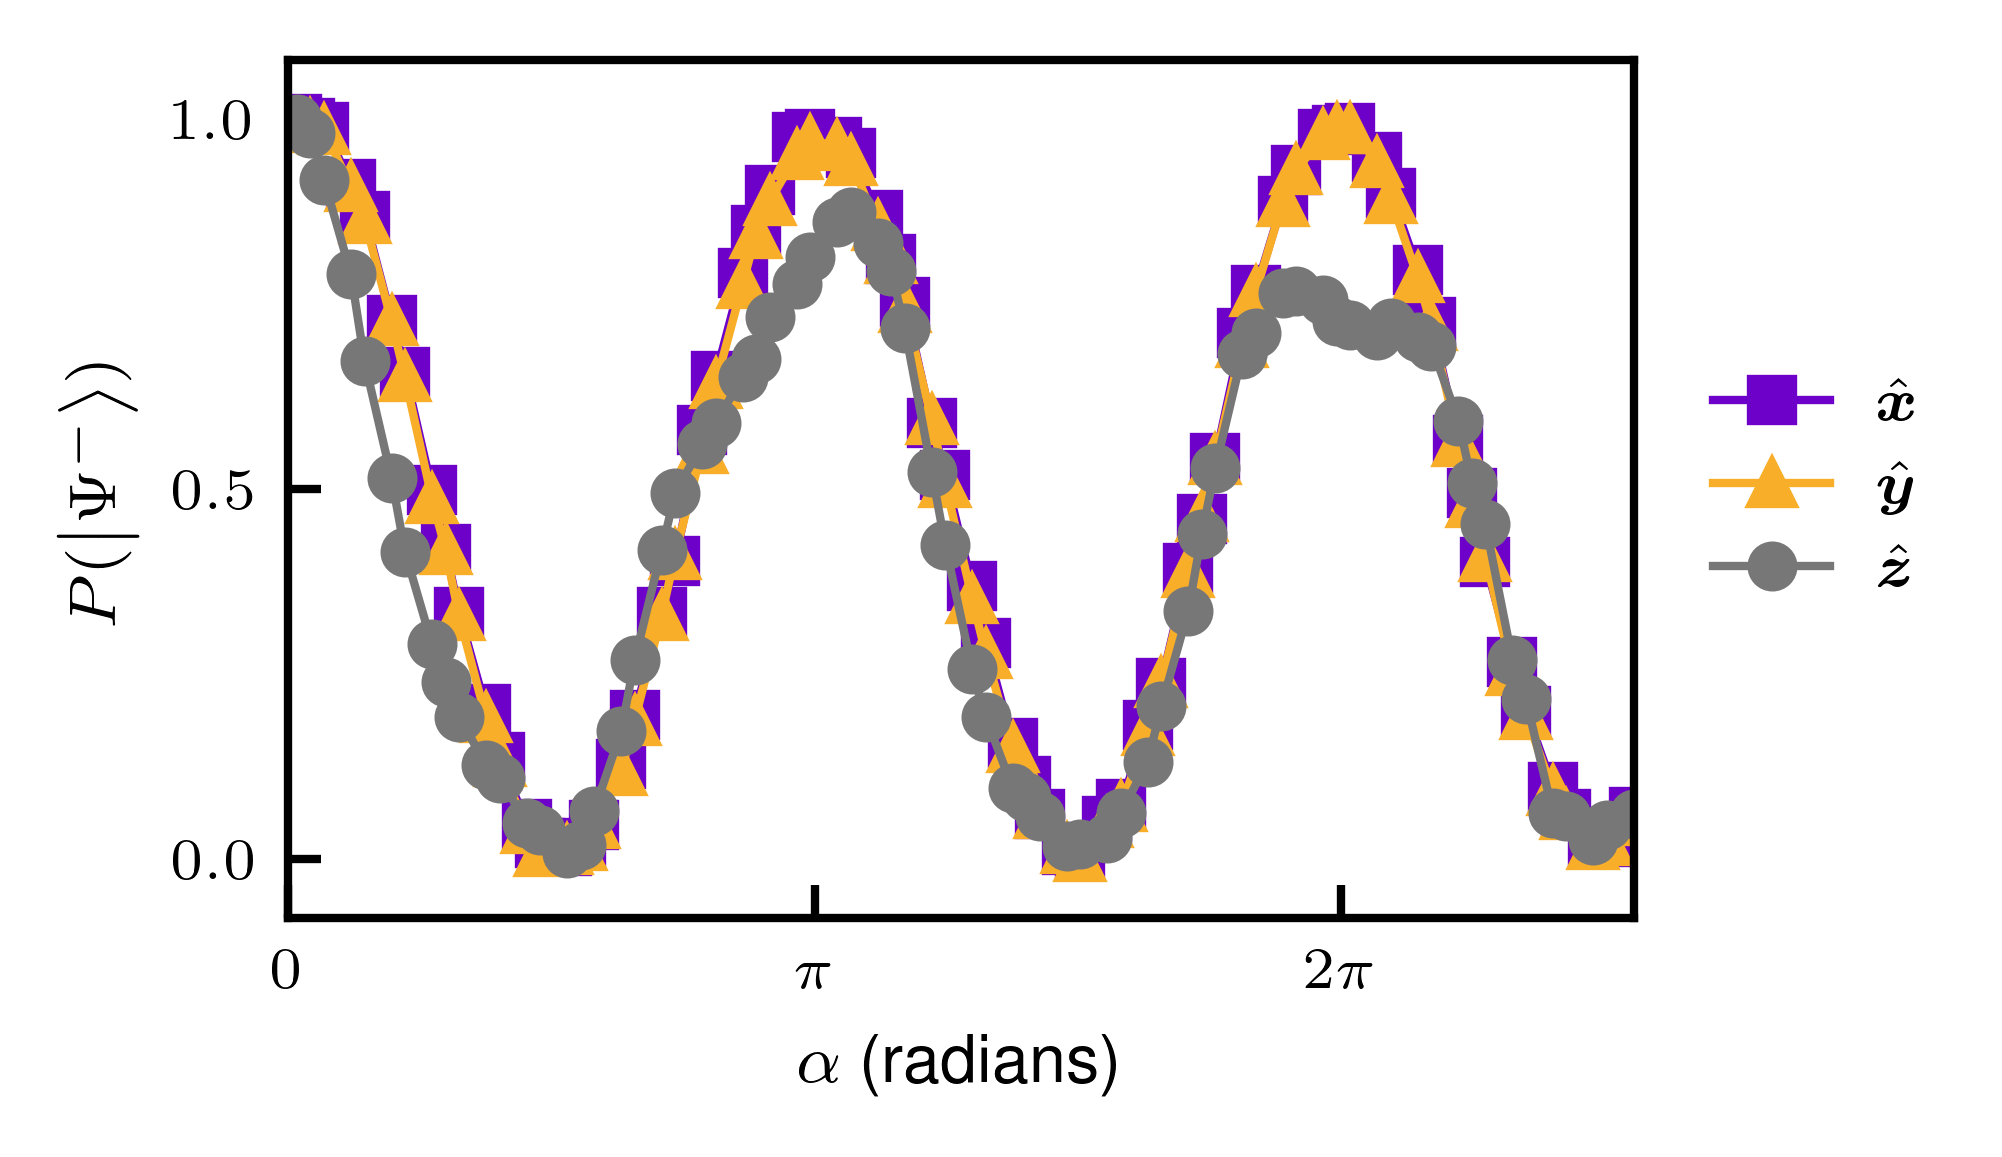

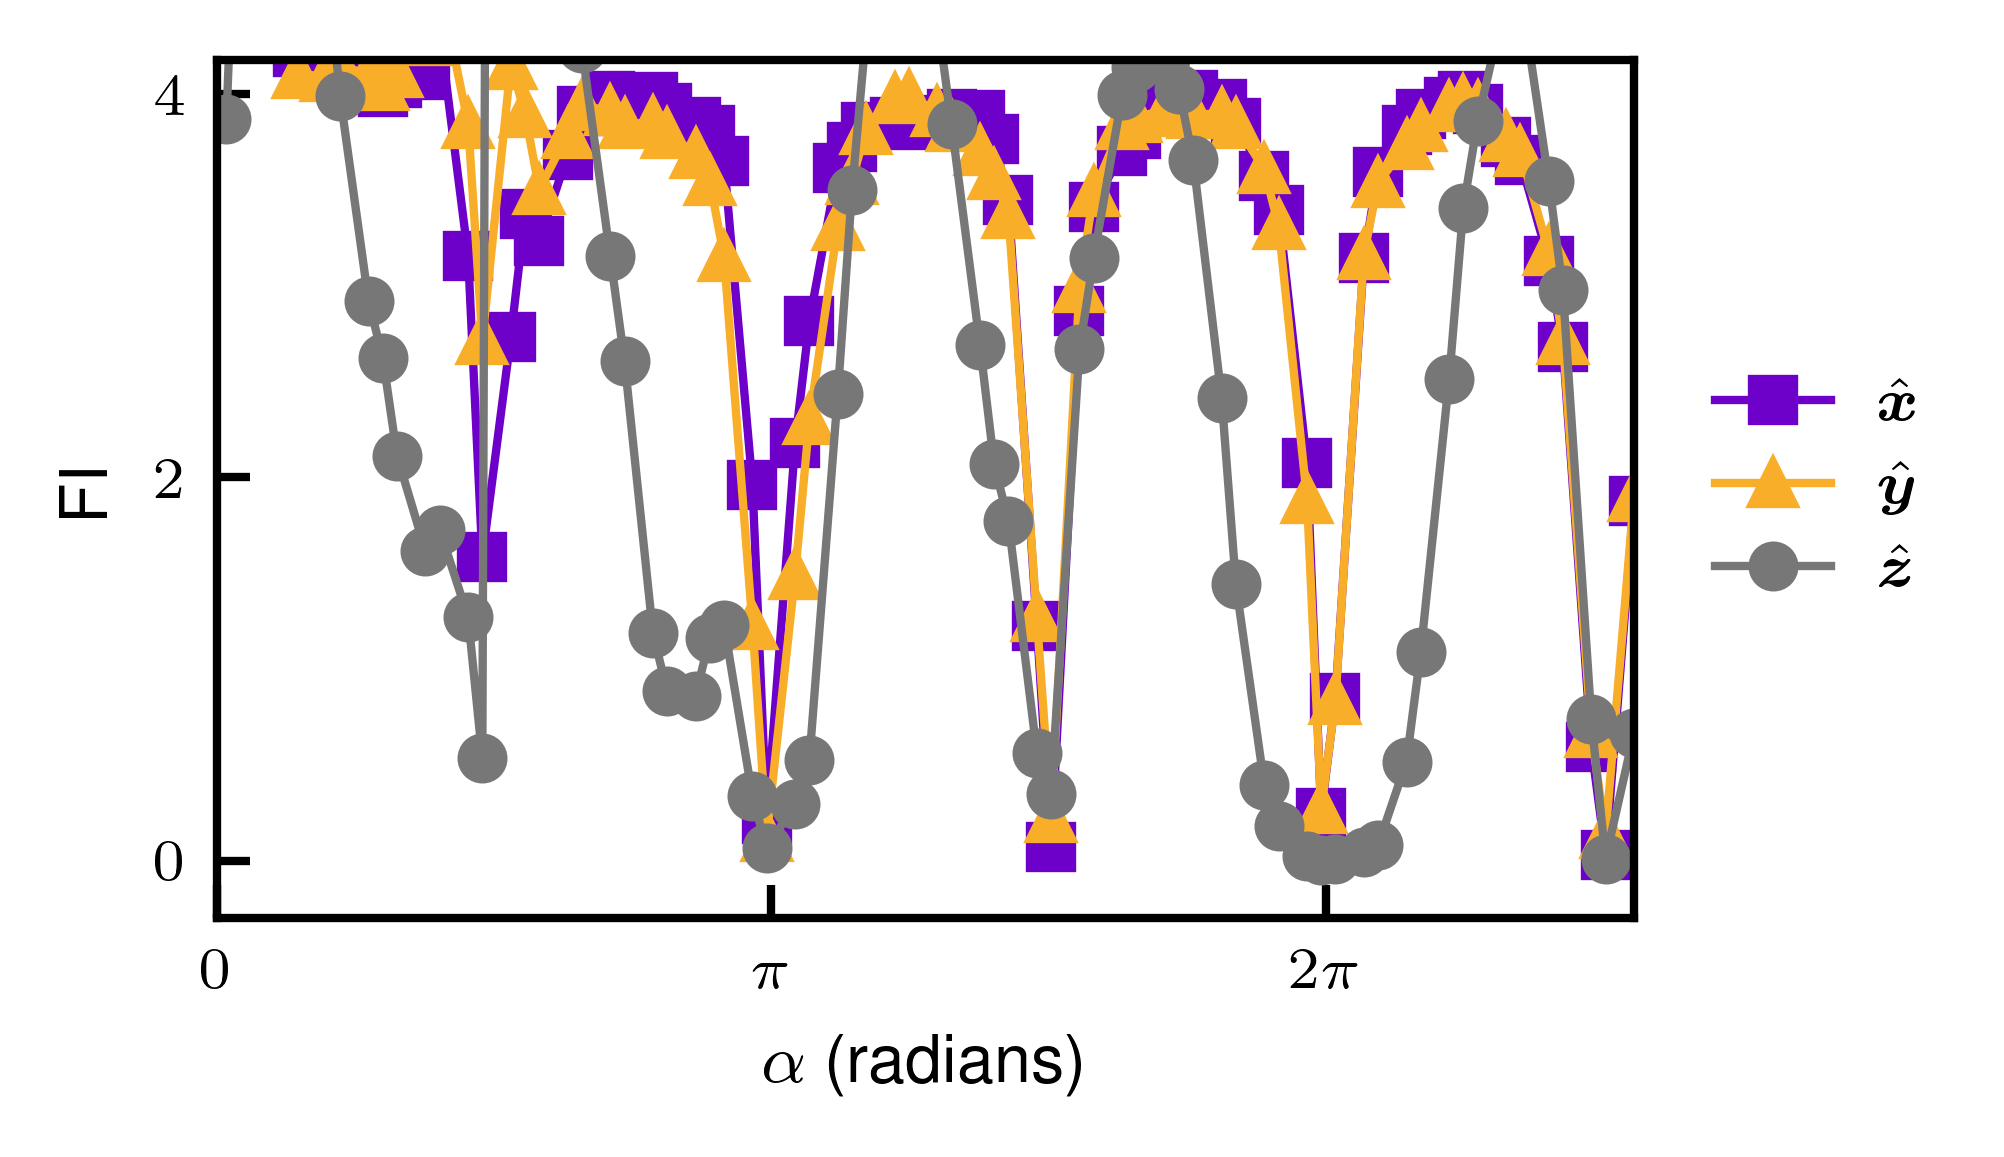

In [20]:
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# P(|Psi->) combined
fig, ax = plt.subplots(figsize=fig_size, dpi=600)
ax.plot(alpha_common_ds, P_Ux_ds, **style_x)
ax.plot(alpha_common_ds, P_Uy_ds, **style_y)
ax.plot(alpha_common_ds, P_Uz_ds, **style_z)

ax.set_xlim(alpha_xlim_min, alpha_xlim_max)
ax.set_ylim(-0.08, 1.08)
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_yticks([0, 0.5, 1])
ax.set_xlabel(r'$\alpha$ (radians)')
ax.set_ylabel(fr'$P({ket_psi})$')
ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1.02, 0.5))

ax.tick_params(axis='both', which='both', direction='in')
ax.tick_params(axis='x', which='major', bottom=True, top=False, labelbottom=True,
               length=4, width=lw, direction='in')
ax.tick_params(axis='y', which='major', left=True, right=False, labelleft=True,
               length=4, width=lw, direction='in')

fig.tight_layout()
outpath_p = os.path.join('si_figures', 'SI_fig_v2_gate_P_combined.pdf')
os.makedirs(os.path.dirname(outpath_p), exist_ok=True)
fig.savefig(outpath_p, bbox_inches='tight')
plt.show()

# FI combined
fig, ax = plt.subplots(figsize=fig_size, dpi=600)
ax.plot(alpha_common_ds, FI_Ux_ds, **style_x)
ax.plot(alpha_common_ds, FI_Uy_ds, **style_y)
ax.plot(alpha_common_ds, FI_Uz_ds, **style_z)

ax.set_xlim(alpha_xlim_min, alpha_xlim_max)
ax.set_ylim(-0.3, 4.18)
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_yticks([0, 2, 4])
ax.set_xlabel(r'$\alpha$ (radians)')
ax.set_ylabel('FI')
ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1.02, 0.5))

ax.tick_params(axis='both', which='both', direction='in')
ax.tick_params(axis='x', which='major', bottom=True, top=False, labelbottom=True,
               length=4, width=lw, direction='in')
ax.tick_params(axis='y', which='major', left=True, right=False, labelleft=True,
               length=4, width=lw, direction='in')

fig.tight_layout()
outpath_fi = os.path.join('si_figures', 'SI_fig_v2_gate_FI_combined.pdf')
fig.savefig(outpath_fi, bbox_inches='tight')
plt.show()







## Gate-fidelity-corrected average FI

The mean FI curve is shown together with a horizontal average line.
For this gate-corrected case, singular values above 4 are excluded when computing the horizontal average level.


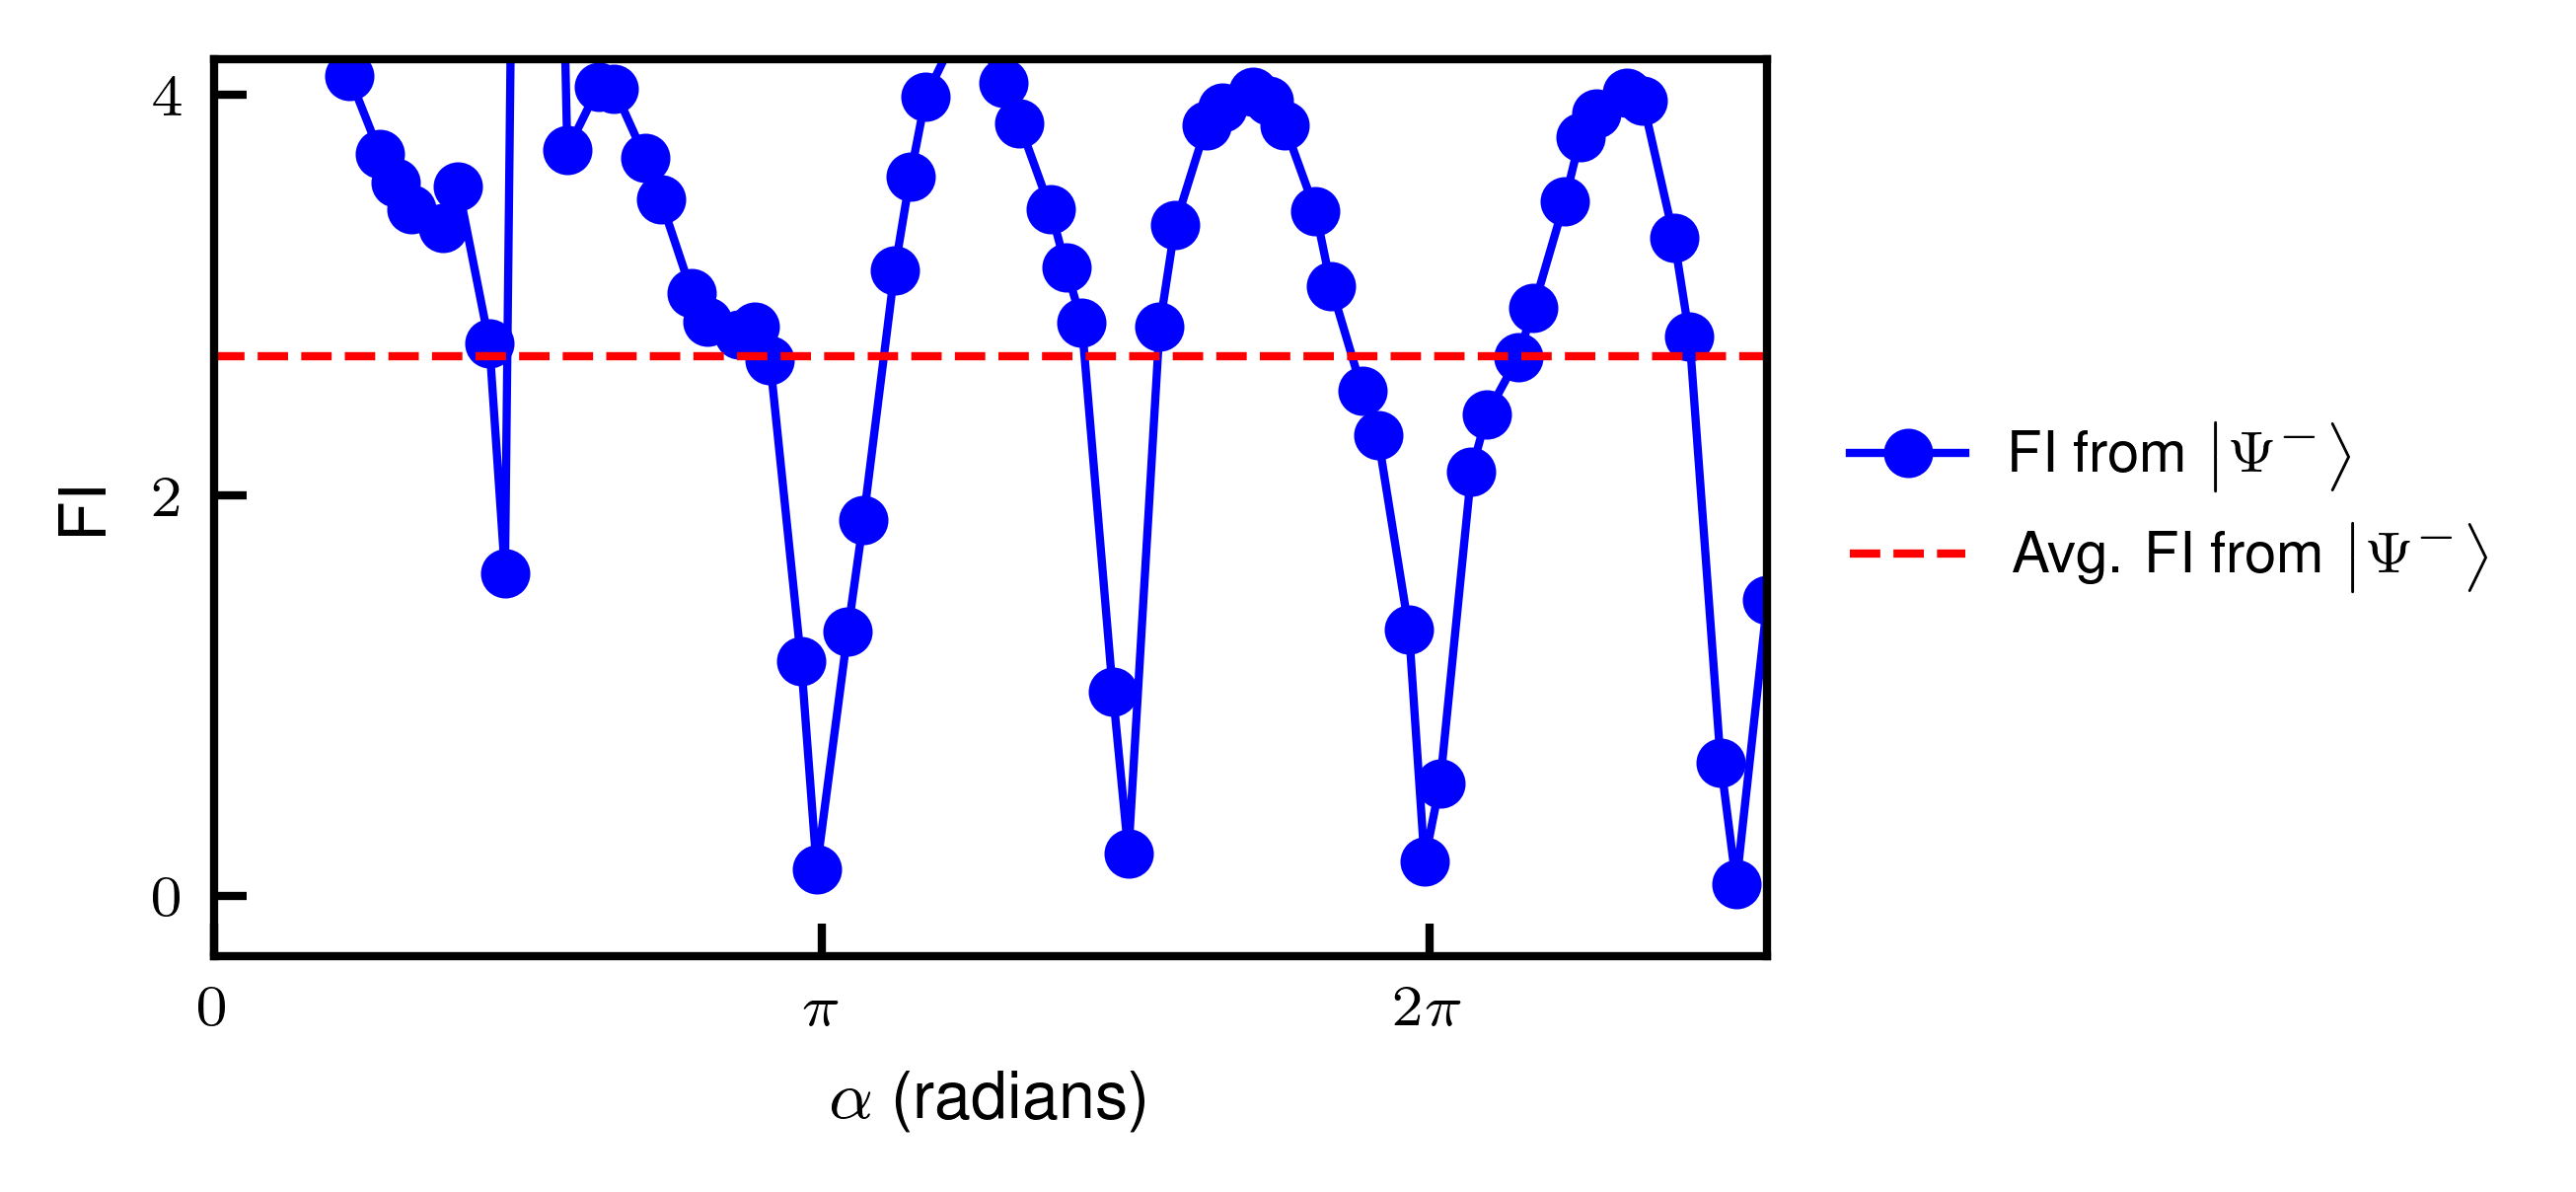

Average FI level (<=4 only): 2.6942946660547085


In [21]:
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

style_mean = dict(color='blue', marker='o', linestyle='-', markersize=5.0, label=fr'FI from ${ket_psi}$')
style_hline = dict(color='red', linestyle='--', linewidth=1.0, label=fr'Avg. FI from ${ket_psi}$')

singlet_Uxyz_mean_FI_ds_gate = FI_mean_ds
valid_mask = np.isfinite(singlet_Uxyz_mean_FI_ds_gate) & (singlet_Uxyz_mean_FI_ds_gate <= 4)
singlet_FI_ds_gate_mean = np.mean(singlet_Uxyz_mean_FI_ds_gate[valid_mask])

fig, ax = plt.subplots(figsize=fig_size, dpi=600)
ax.plot(alpha_common_ds, singlet_Uxyz_mean_FI_ds_gate, **style_mean)
ax.axhline(singlet_FI_ds_gate_mean, **style_hline)

ax.set_xlim(alpha_xlim_min, alpha_xlim_max)
ax.set_ylim(-0.3, 4.18)
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_yticks([0, 2, 4])
ax.set_xlabel(r'$\alpha$ (radians)')
ax.set_ylabel('FI')
ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1.02, 0.5))

ax.tick_params(axis='both', which='both', direction='in')
ax.tick_params(axis='x', which='major', bottom=True, top=False, labelbottom=True,
               length=4, width=lw, direction='in')
ax.tick_params(axis='y', which='major', left=True, right=False, labelleft=True,
               length=4, width=lw, direction='in')

outpath = os.path.join('si_figures', 'SI_fig_v3_c_gate.pdf')
os.makedirs(os.path.dirname(outpath), exist_ok=True)
fig.savefig(outpath, bbox_inches='tight')
plt.show()

print('Average FI level (<=4 only):', singlet_FI_ds_gate_mean)





